# Programme 1 — Prévision de la demande (Forecasting mensuel)

**Rôle : Data Scientist** — Plateforme de Data-Driven Pricing & Recommandation

**Objectif (conforme au sujet)** : prédire combien de produits on va
vendre **le mois prochain**, à partir de `date_vente`, `quantite` et
`annee_mois` (colonne déjà préparée par le Data Engineer dans
`ventes_enrichies.parquet`).

**Deux niveaux de prévision** :
1. **Global** (toutes catégories confondues) — Prophet, comme suggéré
   par le prof. C'est le chiffre le plus direct pour répondre à "combien
   on va vendre le mois prochain".
2. **Par catégorie** — LightGBM, plus utile en pratique pour le pricing
   et le réapprovisionnement (chaque catégorie a sa propre dynamique).

Les deux sont comparés à une baseline naïve (mois précédent / moyenne
mobile).

In [1]:
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
OUTPUTS_DIR = Path("../outputs")
MODELS_DIR.mkdir(exist_ok=True, parents=True)
OUTPUTS_DIR.mkdir(exist_ok=True, parents=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mp = mape(y_true, y_pred)
    print(f"{label:35s} | MAE={mae:8.2f}  RMSE={rmse:8.2f}  MAPE={mp:6.1f}%")
    return {"label": label, "mae": mae, "rmse": rmse, "mape": mp}

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Chargement des données

In [2]:
ventes = pd.read_parquet(DATA_DIR / "ventes_enrichies.parquet")
ventes["date_vente"] = pd.to_datetime(ventes["date_vente"])

# On borne à la période d'historique continue (le reste, ce sont quelques
# ventes streaming isolées de test très postérieures, qui créeraient un
# trou de plusieurs mois dans la série mensuelle).
ventes = ventes[ventes["date_vente"] <= "2025-07-31"].copy()

print(f"Ventes : {ventes.shape[0]} lignes")
print(f"Période : {ventes['annee_mois'].min()} -> {ventes['annee_mois'].max()} "
      f"({ventes['annee_mois'].nunique()} mois)")

Ventes : 15000 lignes
Période : 2024-08 -> 2025-07 (12 mois)


## 2. Série mensuelle globale (colonnes : date_vente, quantite, annee_mois)

   annee_mois  quantite         ca
0     2024-08       894  270345.50
1     2024-09      1479  433852.74
2     2024-10      1572  454039.28
3     2024-11      2155  605525.31
4     2024-12      2588  780291.54
5     2025-01      1316  388489.55
6     2025-02      1124  326468.75
7     2025-03      1370  395863.66
8     2025-04      1272  380465.53
9     2025-05      1464  432816.13
10    2025-06      1421  410547.96
11    2025-07       918  265738.48


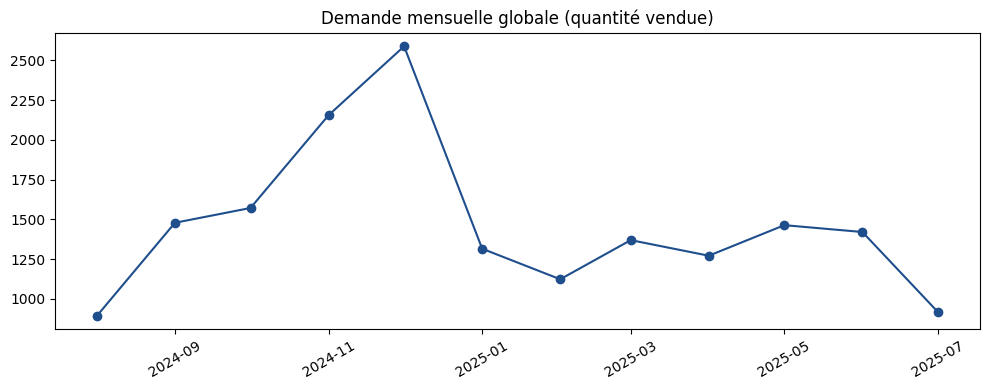

In [3]:
demande_mensuelle_globale = (
    ventes.groupby("annee_mois")
    .agg(quantite=("quantite", "sum"), ca=("montant_total", "sum"))
    .reset_index()
)
demande_mensuelle_globale["ds"] = pd.to_datetime(demande_mensuelle_globale["annee_mois"] + "-01")
demande_mensuelle_globale = demande_mensuelle_globale.sort_values("ds").reset_index(drop=True)

print(demande_mensuelle_globale[["annee_mois", "quantite", "ca"]])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(demande_mensuelle_globale["ds"], demande_mensuelle_globale["quantite"], marker="o", color="#1f4e8c")
ax.set_title("Demande mensuelle globale (quantité vendue)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "forecasting_serie_mensuelle_globale.png", dpi=120)
plt.show()

## 3. Prévision globale avec Prophet

**Split** : les 2 derniers mois complets en test (le dernier mois de
l'historique est souvent partiel selon la date d'extraction — on l'exclut
du test s'il l'est).

In [4]:
serie = demande_mensuelle_globale[["ds", "quantite"]].rename(columns={"quantite": "y"})

n_test = 2
train_serie = serie.iloc[:-n_test]
test_serie = serie.iloc[-n_test:]

print(f"Train : {len(train_serie)} mois | Test : {len(test_serie)} mois ({test_serie['ds'].dt.strftime('%Y-%m').tolist()})")

model_prophet = Prophet(
    yearly_seasonality=False,   # < 2 ans d'historique : pas assez pour estimer une saisonnalité annuelle fiable
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
)
model_prophet.fit(train_serie)

futur = model_prophet.make_future_dataframe(periods=n_test, freq="MS")
forecast = model_prophet.predict(futur)
pred_prophet = forecast.tail(n_test)["yhat"].clip(lower=0).values

resultats_global = []
resultats_global.append(evaluate(test_serie["y"], [train_serie["y"].iloc[-1]] * n_test, "Baseline naïve (mois -1)"))
resultats_global.append(evaluate(test_serie["y"], [train_serie["y"].tail(3).mean()] * n_test, "Baseline moyenne mobile 3 mois"))
resultats_global.append(evaluate(test_serie["y"], pred_prophet, "Prophet"))

21:19:53 - cmdstanpy - INFO - Chain [1] start processing


21:19:53 - cmdstanpy - INFO - Chain [1] done processing


Train : 10 mois | Test : 2 mois (['2025-06', '2025-07'])
Baseline naïve (mois -1)            | MAE=  294.50  RMSE=  387.28  MAPE=  31.3%
Baseline moyenne mobile 3 mois      | MAE=  251.50  RMSE=  320.81  MAPE=  26.4%
Prophet                             | MAE=  290.95  RMSE=  381.24  MAPE=  30.8%


## 4. Prévision du mois suivant (le vrai livrable métier)

On ré-entraîne Prophet sur **tout** l'historique disponible pour prédire
le mois qui suit la dernière donnée connue — c'est la question posée par
le sujet : "combien va-t-on vendre le mois prochain ?"

21:19:53 - cmdstanpy - INFO - Chain [1] start processing


21:19:53 - cmdstanpy - INFO - Chain [1] done processing


Prévision pour 2025-08 : 1253 unités (intervalle 686-1867)


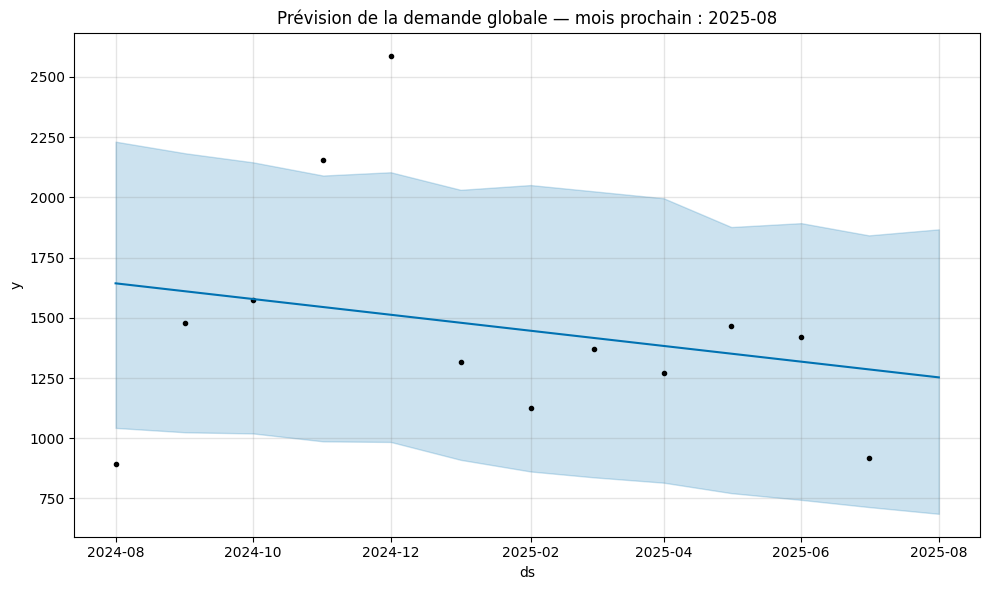

In [5]:
model_prophet_full = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
)
model_prophet_full.fit(serie)

futur_full = model_prophet_full.make_future_dataframe(periods=1, freq="MS")
forecast_full = model_prophet_full.predict(futur_full)
prochain_mois = forecast_full.tail(1)
prochain_mois_date = prochain_mois["ds"].dt.strftime("%Y-%m").values[0]
prochaine_quantite = max(0, round(prochain_mois["yhat"].values[0]))
borne_basse = max(0, round(prochain_mois["yhat_lower"].values[0]))
borne_haute = round(prochain_mois["yhat_upper"].values[0])

print(f"Prévision pour {prochain_mois_date} : {prochaine_quantite} unités "
      f"(intervalle {borne_basse}-{borne_haute})")

fig = model_prophet_full.plot(forecast_full)
plt.title(f"Prévision de la demande globale — mois prochain : {prochain_mois_date}")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "forecasting_prophet_prochain_mois.png", dpi=120)
plt.show()

## 5. Prévision détaillée par catégorie (LightGBM)

Utile pour le pricing/réapprovisionnement, qui se décide par catégorie
et pas seulement en global.

In [6]:
demande_mensuelle_cat = (
    ventes.groupby(["annee_mois", "categorie"])
    .agg(quantite=("quantite", "sum"))
    .reset_index()
)
demande_mensuelle_cat["ds"] = pd.to_datetime(demande_mensuelle_cat["annee_mois"] + "-01")

toutes_categories = sorted(ventes["categorie"].unique())
tous_mois = sorted(demande_mensuelle_cat["ds"].unique())
grille = pd.MultiIndex.from_product([tous_mois, toutes_categories], names=["ds", "categorie"]).to_frame(index=False)
demande_mensuelle_cat = grille.merge(demande_mensuelle_cat[["ds", "categorie", "quantite"]], on=["ds", "categorie"], how="left").fillna({"quantite": 0})
demande_mensuelle_cat = demande_mensuelle_cat.sort_values(["categorie", "ds"]).reset_index(drop=True)


def add_features(df):
    df = df.copy()
    df["mois_num"] = df["ds"].dt.month
    df["periode_fetes"] = df["mois_num"].isin([11, 12]).astype(int)
    for lag in [1, 2]:
        df[f"lag_{lag}"] = df["quantite"].shift(lag)
    df["rolling_mean_3"] = df["quantite"].shift(1).rolling(3).mean()
    return df


pieces = []
for cat, g in demande_mensuelle_cat.groupby("categorie"):
    g2 = add_features(g)
    g2["categorie"] = cat
    pieces.append(g2)
demande_cat_feat = pd.concat(pieces, ignore_index=True).dropna().reset_index(drop=True)

cat_encoded = pd.get_dummies(demande_cat_feat["categorie"], prefix="cat")
demande_cat_feat = pd.concat([demande_cat_feat, cat_encoded], axis=1)

feature_cols_cat = ["mois_num", "periode_fetes", "lag_1", "lag_2", "rolling_mean_3"] + list(cat_encoded.columns)

cutoff_cat = sorted(demande_cat_feat["ds"].unique())[-2]
train_cat = demande_cat_feat[demande_cat_feat["ds"] < cutoff_cat]
test_cat = demande_cat_feat[demande_cat_feat["ds"] >= cutoff_cat]

print(f"Train catégorie : {len(train_cat)} lignes | Test : {len(test_cat)} lignes")

model_lgb_cat = lgb.LGBMRegressor(
    n_estimators=60, learning_rate=0.05, max_depth=3, num_leaves=7,
    min_child_samples=5, reg_alpha=1.0, reg_lambda=1.0, random_state=42, verbosity=-1,
)
model_lgb_cat.fit(train_cat[feature_cols_cat], train_cat["quantite"])
pred_cat = np.clip(model_lgb_cat.predict(test_cat[feature_cols_cat]), 0, None)

resultats_cat = []
resultats_cat.append(evaluate(test_cat["quantite"], test_cat["lag_1"], "Baseline naïve par catégorie (mois -1)"))
resultats_cat.append(evaluate(test_cat["quantite"], pred_cat, "LightGBM par catégorie"))

comparatif_categorie = test_cat[["ds", "categorie", "quantite"]].copy()
comparatif_categorie["prediction"] = pred_cat
comparatif_categorie["annee_mois"] = comparatif_categorie["ds"].dt.strftime("%Y-%m")
print(comparatif_categorie[["annee_mois", "categorie", "quantite", "prediction"]].to_string(index=False))

Train catégorie : 56 lignes | Test : 16 lignes
Baseline naïve par catégorie (mois -1) | MAE=   41.25  RMSE=   50.50  MAPE=  34.6%
LightGBM par catégorie              | MAE=   44.69  RMSE=   54.16  MAPE=  38.5%
annee_mois       categorie  quantite  prediction
   2025-06  Beauté & Santé       140  177.613619
   2025-07  Beauté & Santé       118  166.256195
   2025-06  Enfants & Bébé       137  148.035039
   2025-07  Enfants & Bébé        80  148.035039
   2025-06 Livres & Médias       156  185.475291
   2025-07 Livres & Médias       110  185.475291
   2025-06   Maison & Déco       217  221.076608
   2025-07   Maison & Déco       138  221.076608
   2025-06      Mode Femme       193  185.965888
   2025-07      Mode Femme       121  187.353494
   2025-06      Mode Homme       219  225.200633
   2025-07      Mode Homme       141  225.200633
   2025-06 Sport & Loisirs       171  185.475291
   2025-07 Sport & Loisirs       128  185.475291
   2025-06    Électronique       188  161.309675
   202

## 6. Comparaison visuelle des méthodes

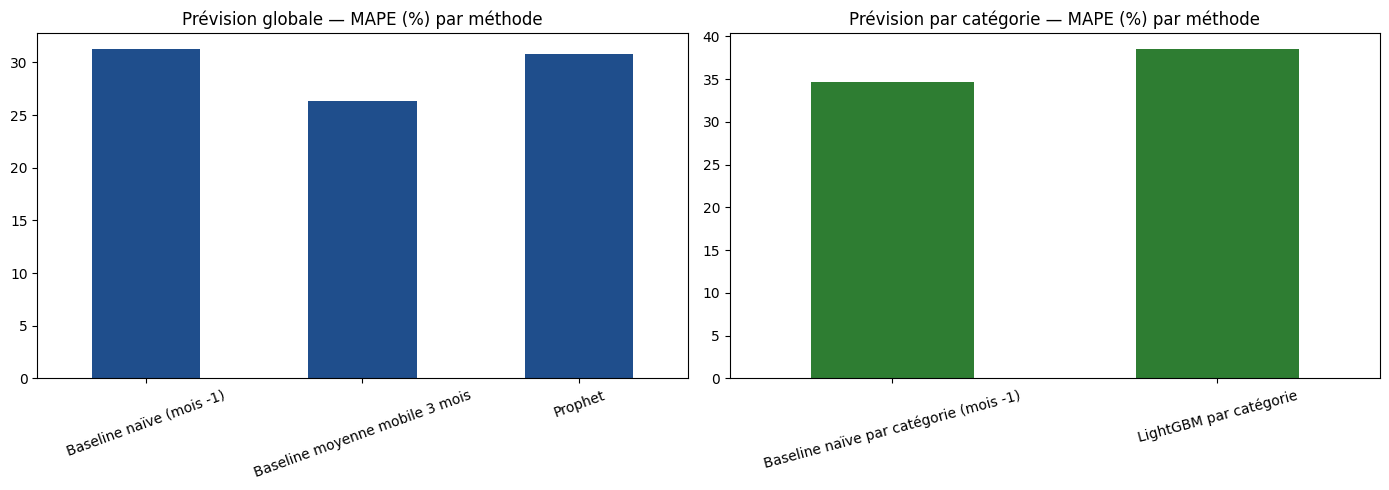

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_df_global = pd.DataFrame(resultats_global)
res_df_global.plot.bar(x="label", y="mape", ax=axes[0], legend=False, color="#1f4e8c")
axes[0].set_title("Prévision globale — MAPE (%) par méthode")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

res_df_cat = pd.DataFrame(resultats_cat)
res_df_cat.plot.bar(x="label", y="mape", ax=axes[1], legend=False, color="#2e7d32")
axes[1].set_title("Prévision par catégorie — MAPE (%) par méthode")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "forecasting_comparaison_methodes.png", dpi=120)
plt.show()

## 7. Sauvegarde des modèles et métriques

In [8]:
import pickle

with open(MODELS_DIR / "forecasting_prophet_global.pkl", "wb") as f:
    pickle.dump(model_prophet_full, f)

model_lgb_cat.booster_.save_model(str(MODELS_DIR / "forecasting_lightgbm_categorie.txt"))
with open(MODELS_DIR / "forecasting_categorie_features.json", "w") as f:
    json.dump({"feature_cols": feature_cols_cat, "categories": toutes_categories}, f, indent=2, ensure_ascii=False)

metriques_finales = {
    "prevision_globale": {
        "methode_retenue": "Prophet",
        "prochain_mois": prochain_mois_date,
        "quantite_prevue": int(prochaine_quantite),
        "intervalle_confiance": [int(borne_basse), int(borne_haute)],
        "comparatif_methodes": resultats_global,
    },
    "prevision_par_categorie": {
        "methode_retenue": "LightGBM",
        "comparatif_methodes": resultats_cat,
    },
}
with open(OUTPUTS_DIR / "forecasting_metrics.json", "w") as f:
    json.dump(metriques_finales, f, indent=2, ensure_ascii=False)

comparatif_categorie[["annee_mois", "categorie", "quantite", "prediction"]].to_csv(
    OUTPUTS_DIR / "forecasting_detail_categorie.csv", index=False
)

print("Modèles sauvegardés dans models/")
print("Métriques sauvegardées : outputs/forecasting_metrics.json")

Modèles sauvegardés dans models/
Métriques sauvegardées : outputs/forecasting_metrics.json


## Conclusion

- **Global (Prophet)** : donne directement le chiffre demandé par le
  sujet — "combien va-t-on vendre le mois prochain" — avec un intervalle
  de confiance, ce qui est plus honnête qu'un chiffre unique vu le peu
  d'historique (12 mois).
- **Par catégorie (LightGBM)** : sur un historique aussi court (2 mois de
  test seulement), les baselines naïves restent compétitives — c'est
  cohérent avec le constat du programme de forecasting hebdomadaire :
  avec si peu de données, un modèle simple et explicable est souvent
  préférable en démarrage de production.
- **Recommandation pour le MLOps** : exposer le nombre prédit + son
  intervalle de confiance (`forecasting_metrics.json`), pas juste un
  chiffre brut — utile pour que le BI/Business Analyst communique une
  fourchette réaliste dans le rapport plutôt qu'une fausse précision.